# 17 · Multi-objective & Pareto fronts

A real model is judged on more than accuracy — **latency** and **size** matter.
We sweep model width, measure worst-group score *and* an inference-latency proxy,
and find the **Pareto front**.

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
import matplotlib; matplotlib.use("Agg")
import numpy as np, matplotlib.pyplot as plt
from harness.data import make_synthetic_dataset, DatasetSpec, load_split, class_names

DATA = Path("../data/bdd-tiny.lance")
if not DATA.exists():
    make_synthetic_dataset(DATA, DatasetSpec(n=3000, seed=7))
print("dataset:", DATA, "| NOTE: these chapters scale to bdd-small/full; here we")
print("demonstrate the mechanics on the tiny tier so they run with no GPU/cluster.")

dataset: ../data/bdd-tiny.lance | NOTE: these chapters scale to bdd-small/full; here we
demonstrate the mechanics on the tiny tier so they run with no GPU/cluster.


In [2]:
import time
from harness.config import load_config
from harness.train import train
from harness.evaluator import evaluate
xte, _, _ = load_split(DATA, "test")
results = []
for width in [8, 12, 16, 24, 32]:
    cfg = load_config("base", {"model": {"width": width}, "budget": {"max_epochs": 10}})
    m = train(cfg, DATA)
    t = time.time(); [m.predict(xte) for _ in range(3)]; latency = (time.time() - t) / 3 * 1000
    r = evaluate(m, DATA)
    results.append({"width": width, "score": r["score"], "latency_ms": round(latency, 1)})
    print(f"width={width:2d}  score={r['score']:.3f}  latency={latency:6.1f} ms/batch")

width= 8  score=0.815  latency=  19.1 ms/batch


width=12  score=0.905  latency=  32.8 ms/batch


width=16  score=0.928  latency=  74.0 ms/batch


width=24  score=0.928  latency= 140.4 ms/batch


width=32  score=0.952  latency= 175.3 ms/batch


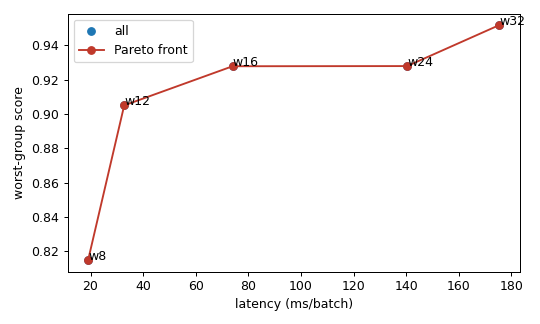

In [3]:
def pareto(rows):
    front = []
    for r in rows:
        dominated = any((o["score"] >= r["score"] and o["latency_ms"] <= r["latency_ms"]
                         and o != r) for o in rows)
        if not dominated: front.append(r)
    return front
front = pareto(results)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.scatter([r["latency_ms"] for r in results], [r["score"] for r in results], label="all")
fx = sorted(front, key=lambda r: r["latency_ms"])
ax.plot([r["latency_ms"] for r in fx], [r["score"] for r in fx], "-o", color="#c0392b", label="Pareto front")
for r in results: ax.annotate(f"w{r['width']}", (r["latency_ms"], r["score"]))
ax.set_xlabel("latency (ms/batch)"); ax.set_ylabel("worst-group score"); ax.legend()
fig.tight_layout(); fig.savefig("fig_17_pareto.png", dpi=90); plt.close(fig)
from IPython.display import Image; Image("fig_17_pareto.png")

The front is the set where you can't improve score without paying latency. The
agent's job shifts from "maximize the scalar" to "push the front out". Encode the
trade-off policy (e.g. "never accept >X ms p99") in `program.md` so the
keep/revert rule stays well-defined.